# Verity prototyping runs — objective run-data explorer

Loads and visualizes the **objective RunReport data** (`results.json`) from every recorded run under
`prototyping-runs/`. These are the data-science prototyping runs of the `fe-kaggle` task
(stellar classification, *balanced accuracy*) across models and time budgets.

Each run is the harness's own machine-readable record — per-cycle gate decisions, proxy hold-out
scores, the live competitive bar, timings, and agent telemetry. Nothing here is hand-entered; it is
parsed straight from the stored reports.

**What to look for:** the score *plateau* (~0.966), where the competitive gate held every submission
back (0 accepted), how the agent spends time/tokens, and the failure modes (timeouts, recursion-limit
crashes).

In [1]:
import json, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (11, 5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.30, "axes.axisbelow": True, "font.size": 11,
})

# Resolve the runs dir whether the notebook runs from its own folder or the repo root.
_CANDIDATES = [
    Path("prototyping-runs"),
    Path("prototyping_datasci_test/prototyping-runs"),
    Path(__file__).resolve().parent / "prototyping-runs" if "__file__" in dir() else Path("prototyping-runs"),
]
RUNS_DIR = next((p for p in _CANDIDATES if p.exists()), _CANDIDATES[0])
print("runs dir:", RUNS_DIR.resolve())
sorted(p.parent.name for p in RUNS_DIR.glob("*/results.json"))

runs dir: /Users/joshuaziel/Documents/coding/verity/prototyping_datasci_test/prototyping-runs


['2026-06-21-gpt5.4-fulldata',
 '2026-06-21-sonnet-fulldata',
 '2026-06-22-sonnet-nudge-fulldata',
 '2026-06-23-fugu-fulldata',
 '2026-06-26-fugu-fulldata-rerun',
 '2026-06-27-fugu-fulldata-160min']

## 1. Load — flatten every RunReport into a tidy per-cycle table

In [2]:
GAP_RE = re.compile(r"estimated public score ([\d.]+) vs target ([\d.]+) \(gap ([\d.]+)\)")

# Friendly short labels (fallback to the folder name). Keeps legends readable.
LABELS = {
    "2026-06-21-gpt5.4-fulldata":       "gpt-5.4",
    "2026-06-21-sonnet-fulldata":       "sonnet",
    "2026-06-22-sonnet-nudge-fulldata": "sonnet+nudge",
    "2026-06-23-fugu-fulldata":         "fugu (orig)",
    "2026-06-26-fugu-fulldata-rerun":   "fugu 80min",
    "2026-06-27-fugu-fulldata-160min":  "fugu 160min",
}

def classify_failure(sandbox_error: str | None):
    if not sandbox_error:
        return None
    s = sandbox_error.lower()
    if "timed out" in s:
        return "timeout"
    if "recursion" in s:
        return "recursion-limit"
    if any(k in s for k in ("429", "credit", "balance", "rate limit", "ratelimit", "quota")):
        return "api-credit"
    return "other"

def load_cycles(runs_dir: Path) -> pd.DataFrame:
    rows = []
    for f in sorted(runs_dir.glob("*/results.json")):
        run = f.parent.name
        d = json.loads(f.read_text())
        rep = d.get("report", d)
        model = (rep.get("agent_telemetry") or {}).get("model") or "?"
        for c in rep.get("cycles", []):
            cm = c.get("commit") or {}
            proxy = next((dec.get("score") for dec in (cm.get("decisions") or [])
                          if dec.get("gate") == "proxy-improves" and dec.get("score") is not None), None)
            est = tgt = gap = None
            for dd in cm.get("defects", []) or []:
                m = GAP_RE.search(dd)
                if m:
                    est, tgt, gap = (float(x) for x in m.groups())
            tm = c.get("timings") or {}
            wall_ms = tm.get("cycle_ms") or tm.get("sandbox_ms")
            tel = c.get("agent_telemetry") or {}
            se = c.get("sandbox_error")
            rows.append(dict(
                run=run, label=LABELS.get(run, run), model=model, cycle=c["index"],
                outcome=cm.get("outcome") or ("sandbox_failed" if se else "—"),
                failure=classify_failure(se),
                proxy=proxy, est=est, target=tgt, gap=gap,
                wall_min=(wall_ms / 60_000 if wall_ms else np.nan),
                tokens=tel.get("total_tokens"), steps=tel.get("model_steps"), tools=tel.get("tool_calls"),
            ))
    df = pd.DataFrame(rows)
    # Ordered category so plots/tables sort runs chronologically.
    order = list(LABELS.values())
    df["label"] = pd.Categorical(df["label"], categories=order + [l for l in df["label"].unique() if l not in order], ordered=True)
    return df.sort_values(["label", "cycle"]).reset_index(drop=True)

df = load_cycles(RUNS_DIR)

# Agent time budget (sandbox_timeout_s) and turn limit (recursion_limit) are NOT recorded in the
# RunReport — sourced per run from its task config (task.*.json) and README. Minutes = timeout / 60.
CONFIG = {
    "2026-06-21-gpt5.4-fulldata":       dict(budget_min=40,  recursion_limit=200),
    "2026-06-21-sonnet-fulldata":       dict(budget_min=40,  recursion_limit=200),
    "2026-06-22-sonnet-nudge-fulldata": dict(budget_min=40,  recursion_limit=200),
    "2026-06-23-fugu-fulldata":         dict(budget_min=40,  recursion_limit=200),
    "2026-06-26-fugu-fulldata-rerun":   dict(budget_min=80,  recursion_limit=300),
    "2026-06-27-fugu-fulldata-160min":  dict(budget_min=160, recursion_limit=300),
}
df["budget_min"] = df["run"].map(lambda r: CONFIG.get(r, {}).get("budget_min"))
df["recursion_limit"] = df["run"].map(lambda r: CONFIG.get(r, {}).get("recursion_limit"))

print(f"{df['run'].nunique()} runs, {len(df)} cycles")
df.head(12)

6 runs, 58 cycles


,run,label,model,cycle,outcome,failure,proxy,est,target,gap,wall_min,tokens,steps,tools,budget_min,recursion_limit
0,2026-06-21-gpt5.4-fulldata,gpt-5.4,gpt-5.4-2026-03-05,0,revised,NaN,0.965782,0.9658,0.9714,0.0056,1.854583,287603.0,18.0,26.0,40,200
1,2026-06-21-gpt5.4-fulldata,gpt-5.4,gpt-5.4-2026-03-05,1,sandbox_failed,other,NaN,NaN,NaN,NaN,1.128203,NaN,NaN,NaN,40,200
2,2026-06-21-gpt5.4-fulldata,gpt-5.4,gpt-5.4-2026-03-05,2,revised,NaN,0.966133,0.9661,0.9714,0.0052,1.869158,246356.0,17.0,25.0,40,200
3,2026-06-21-gpt5.4-fulldata,gpt-5.4,gpt-5.4-2026-03-05,3,rejected,NaN,NaN,NaN,NaN,NaN,40.837427,566633.0,28.0,36.0,40,200
4,2026-06-21-gpt5.4-fulldata,gpt-5.4,gpt-5.4-2026-03-05,4,revised,NaN,0.965894,0.9659,0.9714,0.0055,3.456551,551443.0,29.0,37.0,40,200
5,2026-06-21-gpt5.4-fulldata,gpt-5.4,gpt-5.4-2026-03-05,5,rejected,NaN,0.958554,0.9586,0.9714,0.0128,14.958578,386124.0,24.0,34.0,40,200
6,2026-06-21-gpt5.4-fulldata,gpt-5.4,gpt-5.4-2026-03-05,6,revised,NaN,0.966138,0.9661,0.9714,0.0052,3.325311,255335.0,17.0,28.0,40,200
7,2026-06-21-gpt5.4-fulldata,gpt-5.4,gpt-5.4-2026-03-05,7,revised,NaN,0.966354,0.9664,0.9714,0.0050,18.437435,363446.0,19.0,35.0,40,200
8,2026-06-21-gpt5.4-fulldata,gpt-5.4,gpt-5.4-2026-03-05,8,revised,NaN,0.966091,0.9661,0.9714,0.0053,19.565927,420368.0,22.0,30.0,40,200
9,2026-06-21-gpt5.4-fulldata,gpt-5.4,gpt-5.4-2026-03-05,9,rejected,NaN,NaN,NaN,NaN,NaN,15.060078,272524.0,16.0,27.0,40,200


## 2. Per-run summary

In [3]:
def _h(mins):  # minutes -> hours
    return mins / 60

summary = (df.groupby("label", observed=True)
    .agg(model=("model", "first"),
         cycles=("cycle", "count"),
         scored=("proxy", lambda s: int(s.notna().sum())),
         best_proxy=("proxy", "max"),
         final_gap=("gap", lambda s: s.dropna().iloc[-1] if s.notna().any() else np.nan),
         revised=("outcome", lambda s: int((s == "revised").sum())),
         accepted=("outcome", lambda s: int((s == "accepted").sum())),
         failed=("outcome", lambda s: int((s == "sandbox_failed").sum())),
         total_wall_h=("wall_min", lambda s: _h(s.sum())),
         total_tokens=("tokens", "sum"))
    .reset_index())
summary

,label,model,cycles,scored,best_proxy,final_gap,revised,accepted,failed,total_wall_h,total_tokens
0,gpt-5.4,gpt-5.4-2026-03-05,10,7,0.966354,0.0053,6,0,1,2.008221,3349832.0
1,sonnet,claude-sonnet-4-6,10,6,0.966672,0.0050,5,0,1,1.826102,7316709.0
2,sonnet+nudge,claude-sonnet-4-6,10,5,0.965840,0.0057,5,0,4,2.800520,4846600.0
3,fugu (orig),fugu,8,3,0.966527,0.0048,3,0,5,3.348584,2537997.0
4,fugu 80min,fugu,10,8,0.966600,0.0057,8,0,2,9.772041,9507835.0
5,fugu 160min,fugu,10,7,0.966765,0.0057,7,0,3,15.964927,8700886.0


## 3. Score trajectory — the plateau

Per-cycle hold-out **balanced accuracy** (`proxy-improves` gate score). Failed cycles (no proposal)
are marked with an ✕ on the baseline. The dashed line is the **live top-10% competitive bar** the
gate measures against (median across cycles) — note **no run ever reaches it**, so the gate accepted
nothing and spent zero Kaggle submissions.

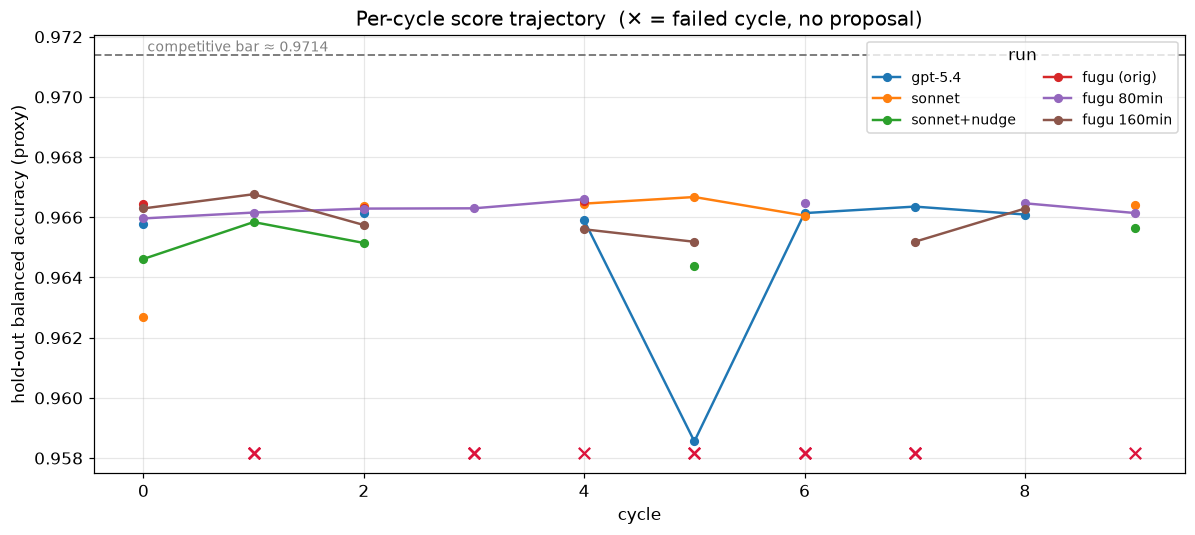

In [4]:
fig, ax = plt.subplots()
bar = df["target"].median()
for label, g in df.groupby("label", observed=True):
    g = g.sort_values("cycle")
    ax.plot(g["cycle"], g["proxy"], marker="o", ms=5, lw=1.6, label=str(label))
    fails = g[g["proxy"].isna() & g["outcome"].eq("sandbox_failed")]
    if len(fails):
        ax.scatter(fails["cycle"], [df["proxy"].min() - 0.0004] * len(fails), marker="x", s=55, color="crimson", zorder=5)
if np.isfinite(bar):
    ax.axhline(bar, ls="--", color="gray", lw=1.3)
    ax.text(0.0, bar, f" competitive bar ≈ {bar:.4f}", va="bottom", ha="left", color="gray", fontsize=9)
ax.set_xlabel("cycle"); ax.set_ylabel("hold-out balanced accuracy (proxy)")
ax.set_title("Per-cycle score trajectory  (✕ = failed cycle, no proposal)")
ax.legend(title="run", fontsize=9, ncol=2)
plt.tight_layout(); plt.show()

### Best-so-far per run

The running maximum within each run — the "documented climb." It flattens almost immediately: the
gains after the first couple of cycles are sub-thousandth.

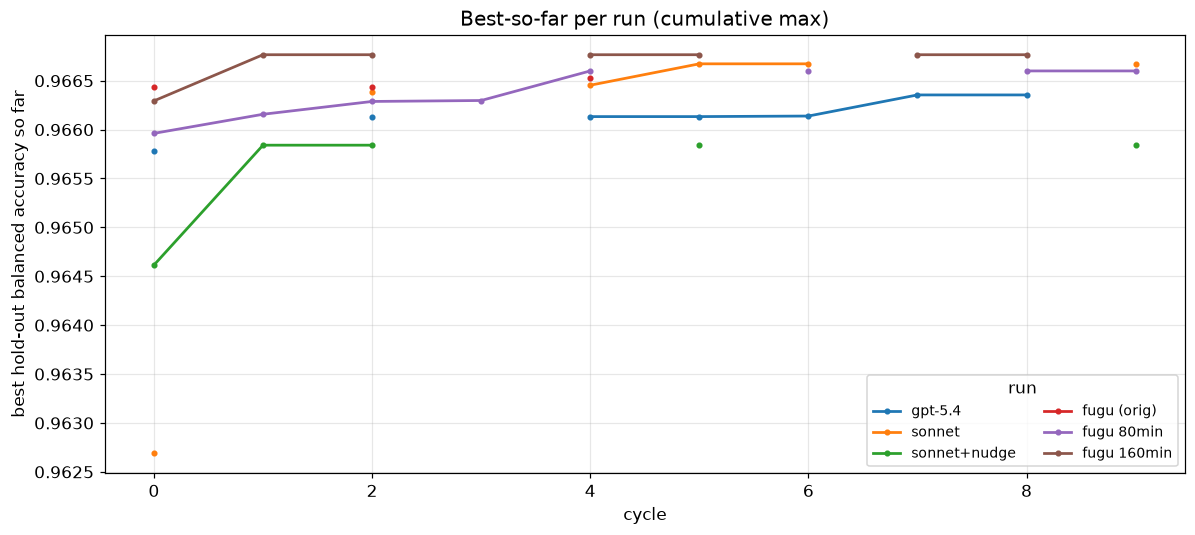

In [5]:
fig, ax = plt.subplots()
for label, g in df.groupby("label", observed=True):
    g = g.sort_values("cycle")
    ax.plot(g["cycle"], g["proxy"].cummax(), marker=".", lw=1.8, label=str(label))
ax.set_xlabel("cycle"); ax.set_ylabel("best hold-out balanced accuracy so far")
ax.set_title("Best-so-far per run (cumulative max)")
ax.legend(title="run", fontsize=9, ncol=2)
plt.tight_layout(); plt.show()

## 4. Gap to the competitive bar

How far each scored cycle's calibrated estimate sits **below** the live top-10% bar. It hovers around
**0.005–0.007 and never closes** — the signature of a methodology/ceiling limit, not a budget one.

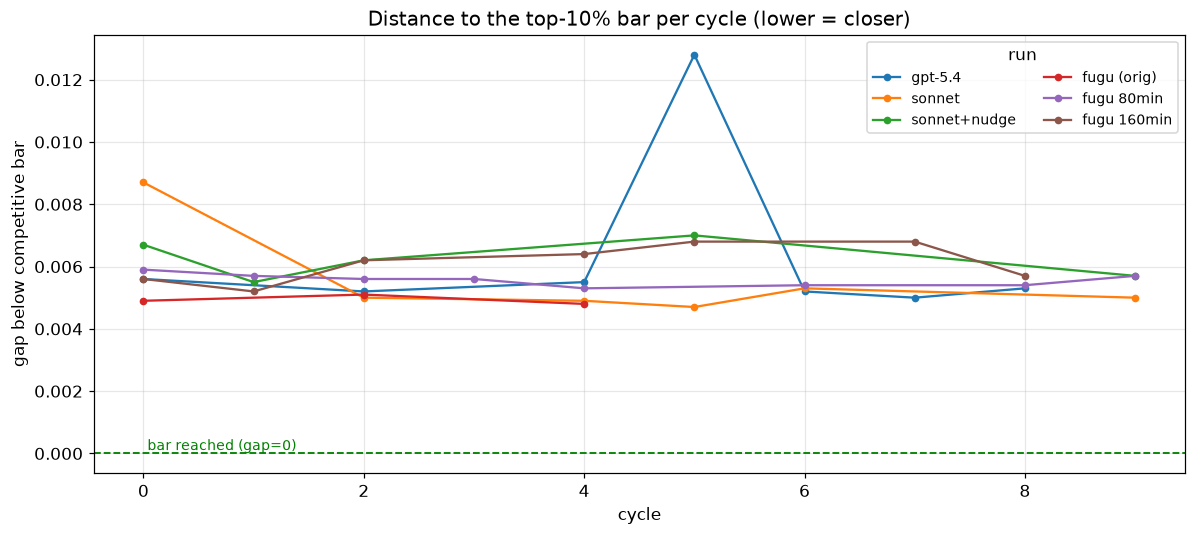

In [6]:
fig, ax = plt.subplots()
for label, g in df.groupby("label", observed=True):
    g = g.dropna(subset=["gap"]).sort_values("cycle")
    if len(g):
        ax.plot(g["cycle"], g["gap"], marker="o", ms=4, lw=1.5, label=str(label))
ax.axhline(0, ls="--", color="green", lw=1.2)
ax.text(0.0, 0, " bar reached (gap=0)", va="bottom", color="green", fontsize=9)
ax.set_xlabel("cycle"); ax.set_ylabel("gap below competitive bar")
ax.set_title("Distance to the top-10% bar per cycle (lower = closer)")
ax.legend(title="run", fontsize=9, ncol=2)
plt.tight_layout(); plt.show()

## 5. Outcomes — every cycle is `revised` or `failed`; nothing accepted

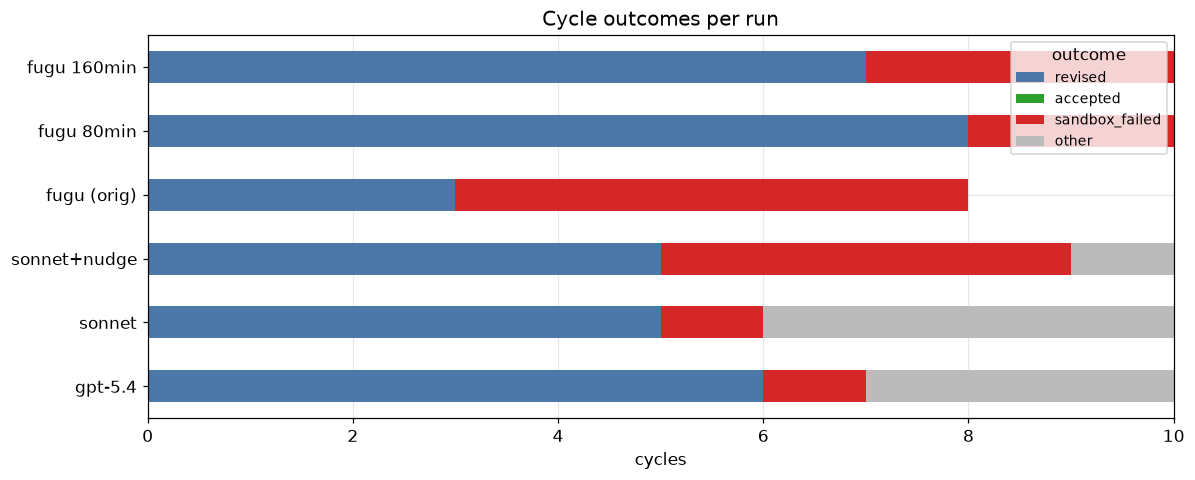

o,revised,accepted,sandbox_failed,other
label,,,,
gpt-5.4,6,0,1,3
sonnet,5,0,1,4
sonnet+nudge,5,0,4,1
fugu (orig),3,0,5,0
fugu 80min,8,0,2,0
fugu 160min,7,0,3,0


In [7]:
piv = (df.assign(o=df["outcome"].where(df["outcome"].isin(["revised", "accepted", "sandbox_failed"]), "other"))
         .pivot_table(index="label", columns="o", values="cycle", aggfunc="count", fill_value=0, observed=True))
for col in ["revised", "accepted", "sandbox_failed", "other"]:
    if col not in piv: piv[col] = 0
piv = piv[["revised", "accepted", "sandbox_failed", "other"]]
colors = {"revised": "#4c78a8", "accepted": "#2ca02c", "sandbox_failed": "#d62728", "other": "#bbbbbb"}
ax = piv.plot(kind="barh", stacked=True, color=[colors[c] for c in piv.columns], figsize=(11, 4.5))
ax.set_xlabel("cycles"); ax.set_ylabel(""); ax.set_title("Cycle outcomes per run")
ax.legend(title="outcome", fontsize=9)
plt.tight_layout(); plt.show()
piv

## 6. Cost — wall time & tokens

The agent **expands to fill whatever budget it is given**: the fugu 80-min and 160-min runs spend far
more wall-clock per cycle than the others, with the 160-min run's longest cycles pushing into the
failure region (timeouts and recursion-limit crashes).

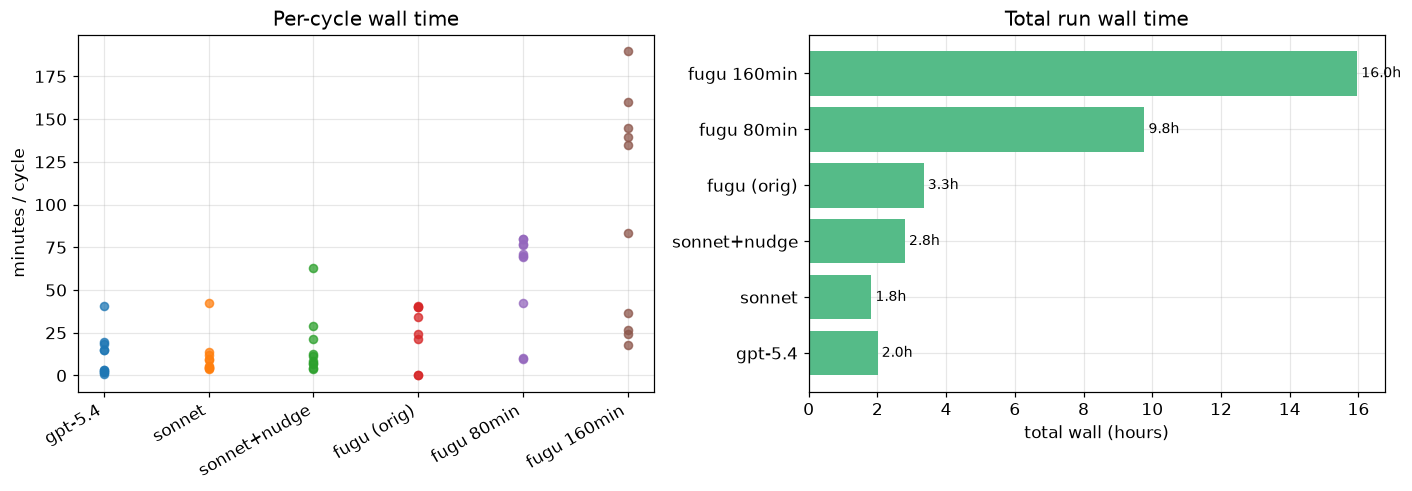

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
# per-cycle wall by run (strip-ish scatter)
for i, (label, g) in enumerate(df.groupby("label", observed=True)):
    axes[0].scatter([i] * len(g), g["wall_min"], s=28, alpha=0.75)
axes[0].set_xticks(range(df["label"].nunique()))
axes[0].set_xticklabels([str(l) for l in df.groupby("label", observed=True).groups], rotation=30, ha="right")
axes[0].set_ylabel("minutes / cycle"); axes[0].set_title("Per-cycle wall time")
# total wall hours per run
tot = df.groupby("label", observed=True)["wall_min"].sum() / 60
axes[1].barh([str(l) for l in tot.index], tot.values, color="#5b8")
axes[1].set_xlabel("total wall (hours)"); axes[1].set_title("Total run wall time")
for y, v in enumerate(tot.values):
    axes[1].text(v, y, f" {v:.1f}h", va="center", fontsize=9)
plt.tight_layout(); plt.show()

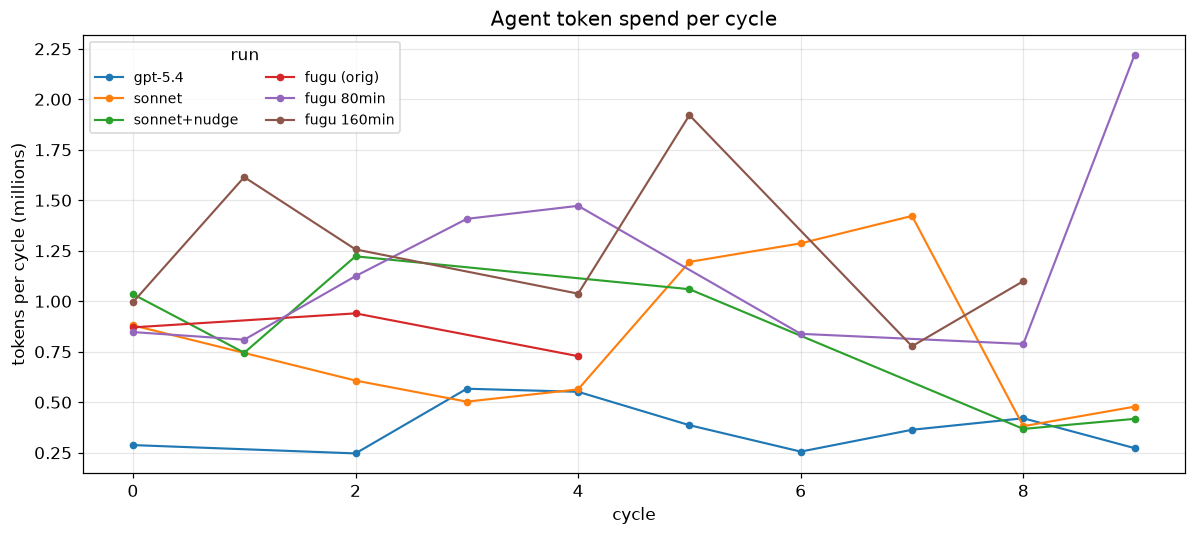

In [9]:
fig, ax = plt.subplots()
for label, g in df.groupby("label", observed=True):
    g = g.dropna(subset=["tokens"]).sort_values("cycle")
    if len(g):
        ax.plot(g["cycle"], g["tokens"] / 1e6, marker="o", ms=4, lw=1.4, label=str(label))
ax.set_xlabel("cycle"); ax.set_ylabel("tokens per cycle (millions)")
ax.set_title("Agent token spend per cycle")
ax.legend(title="run", fontsize=9, ncol=2)
plt.tight_layout(); plt.show()

## 7. The ROI view — best score vs total wall

The payoff question for the time-budget experiment. Doubling the agent budget (fugu 80min → 160min)
moved the best score by **~+0.0002** while **nearly doubling wall time and adding failures** — the
upper-right point buys almost nothing over the one to its left.

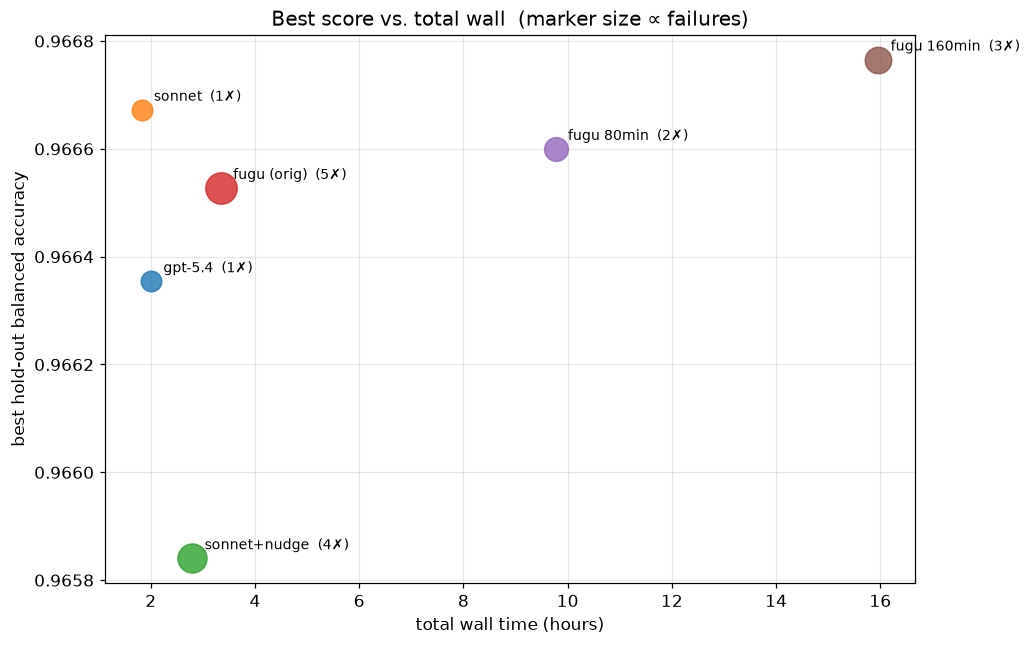

In [10]:
fig, ax = plt.subplots(figsize=(9.5, 6))
for label, g in df.groupby("label", observed=True):
    bw, hh = g["proxy"].max(), g["wall_min"].sum() / 60
    nfail = int((g["outcome"] == "sandbox_failed").sum())
    ax.scatter(hh, bw, s=120 + 60 * nfail, alpha=0.8)
    ax.annotate(f"{label}" + (f"  ({nfail}✗)" if nfail else ""), (hh, bw),
                textcoords="offset points", xytext=(8, 6), fontsize=9)
ax.set_xlabel("total wall time (hours)"); ax.set_ylabel("best hold-out balanced accuracy")
ax.set_title("Best score vs. total wall  (marker size ∝ failures)")
plt.tight_layout(); plt.show()

## 8. Failure modes

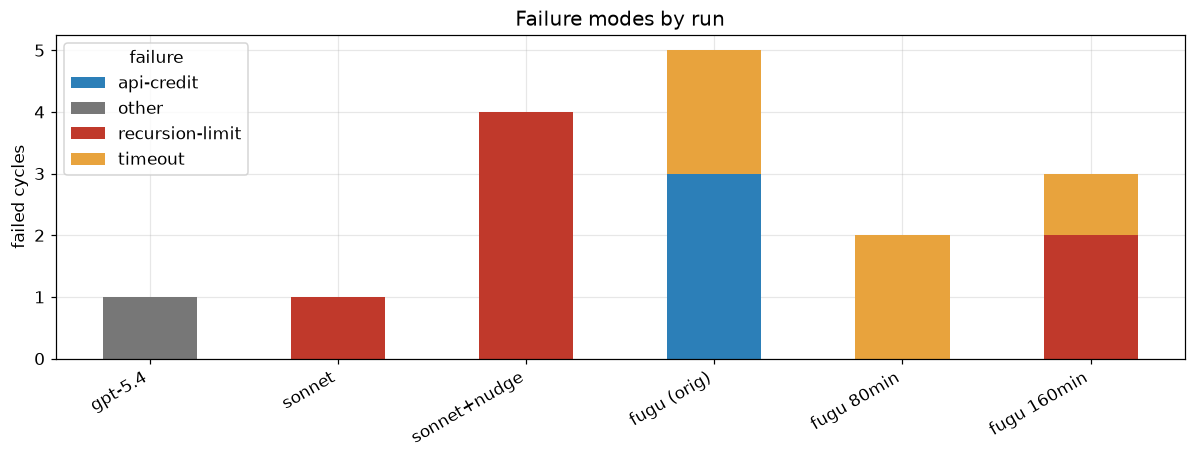

failure,api-credit,other,recursion-limit,timeout
label,,,,
gpt-5.4,0,1,0,0
sonnet,0,0,1,0
sonnet+nudge,0,0,4,0
fugu (orig),3,0,0,2
fugu 80min,0,0,0,2
fugu 160min,0,0,2,1


In [11]:
fdf = df[df["failure"].notna()]
if len(fdf):
    fpiv = fdf.pivot_table(index="label", columns="failure", values="cycle", aggfunc="count", fill_value=0, observed=True)
    _mc = {"timeout": "#e8a33d", "recursion-limit": "#c0392b", "api-credit": "#2c7fb8", "other": "#777"}
    ax = fpiv.plot(kind="bar", stacked=True, figsize=(11, 4.3),
                   color=[_mc.get(c, "#999") for c in fpiv.columns])
    ax.set_ylabel("failed cycles"); ax.set_xlabel(""); ax.set_title("Failure modes by run")
    ax.legend(title="failure"); plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()
    display(fpiv)
else:
    print("no failed cycles recorded")

## 9. Budget & turn-limit vs. failures

The two knobs we varied this session, against the failures they produced. The agent budget
(`sandbox_timeout_s`) and the turn limit (`recursion_limit`) are sourced from each run's task config
(not in the RunReport). **Key story:** there are *two* walls — wall-clock and step-count — and giving
the agent more of one just pushes it into the other.

### 9a. How much time the agent was given vs. failed cycles

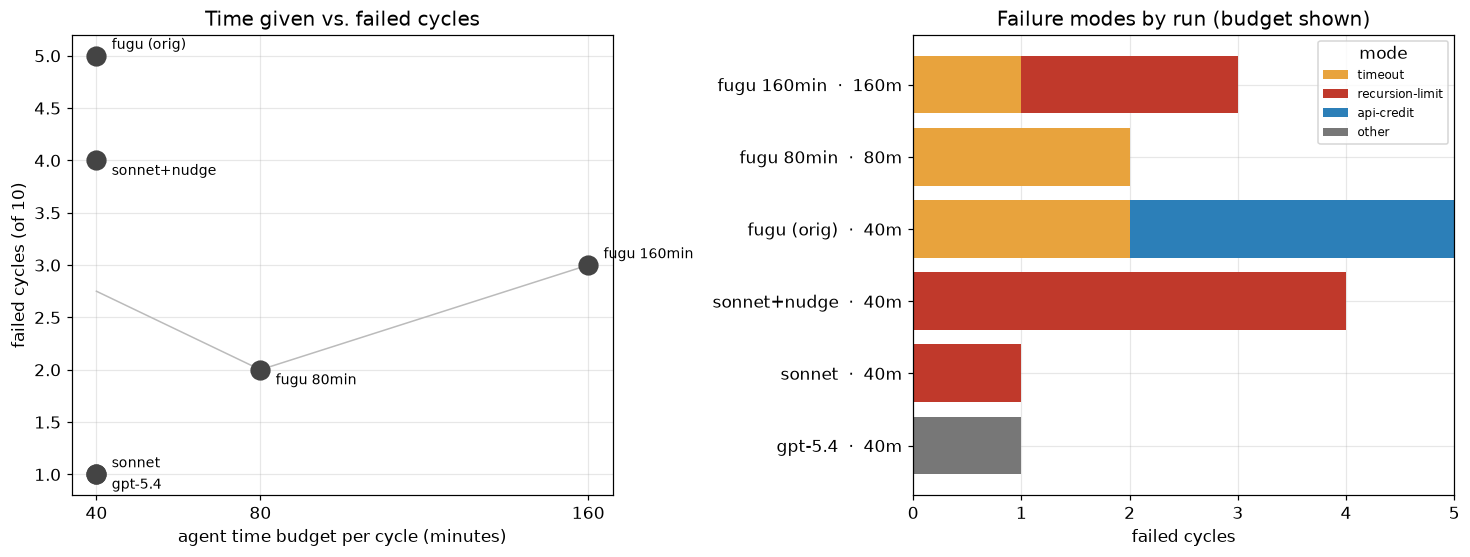

In [12]:
fr = (df.groupby(["run", "label", "budget_min", "recursion_limit", "model"], observed=True)
        .agg(cycles=("cycle", "count"),
             failures=("outcome", lambda s: int((s == "sandbox_failed").sum())))
        .reset_index())

# Stacked failure-mode counts per run (so external api-credit failures are distinguishable).
modes = ["timeout", "recursion-limit", "api-credit", "other"]
fmode = (df[df["failure"].notna()]
         .pivot_table(index="run", columns="failure", values="cycle", aggfunc="count", fill_value=0, observed=True)
         .reindex(columns=modes, fill_value=0))
fr = fr.merge(fmode, left_on="run", right_index=True, how="left").fillna({m: 0 for m in modes})

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.5, 5.2))
mcolor = {"timeout": "#e8a33d", "recursion-limit": "#c0392b", "api-credit": "#2c7fb8", "other": "#777"}

# Left: failures vs the time budget (jittered so the four 40-min runs are readable), annotated.
order = fr.sort_values("budget_min")
rng = np.linspace(-6, 6, len(order))
for (i, (_, r)), dx in zip(enumerate(order.iterrows()), np.resize([-7, 7, -7, 7], len(order))):
    axL.scatter(r["budget_min"], r["failures"], s=150, color="#444", zorder=3)
    axL.annotate(str(r["label"]), (r["budget_min"], r["failures"]),
                 textcoords="offset points", xytext=(10, dx), fontsize=9, va="center")
axL.plot(order.groupby("budget_min")["failures"].mean().index,
         order.groupby("budget_min")["failures"].mean().values, color="#bbb", lw=1, zorder=1)
axL.set_xticks([40, 80, 160]); axL.set_xlabel("agent time budget per cycle (minutes)")
axL.set_ylabel("failed cycles (of 10)"); axL.set_title("Time given vs. failed cycles")

# Right: same runs, failures broken down by mode (runs ordered by budget; budget annotated).
ob = fr.sort_values(["budget_min", "label"])
bottom = np.zeros(len(ob))
for m in modes:
    axR.barh(range(len(ob)), ob[m].values, left=bottom, color=mcolor[m], label=m)
    bottom += ob[m].values
axR.set_yticks(range(len(ob)))
axR.set_yticklabels([f"{l}  ·  {int(b)}m" for l, b in zip(ob["label"], ob["budget_min"])])
axR.set_xlabel("failed cycles"); axR.set_title("Failure modes by run (budget shown)")
axR.legend(title="mode", fontsize=8)
plt.tight_layout(); plt.show()

At the **40-min** budget the agent tends to hit the **step wall first** (recursion-limit crashes,
e.g. sonnet & sonnet+nudge) — or an external limit (fugu's credit exhaustion). Raising the budget to
**80 / 160 min** lets it run long enough to instead hit the **time wall** (timeouts), and at 160 min it
hits *both* (a timeout **and** recursion crashes). More time did not reduce failures — it changed and
ultimately increased them.

### 9b. Turn limit (200 vs 300) vs. recursion-limit crashes

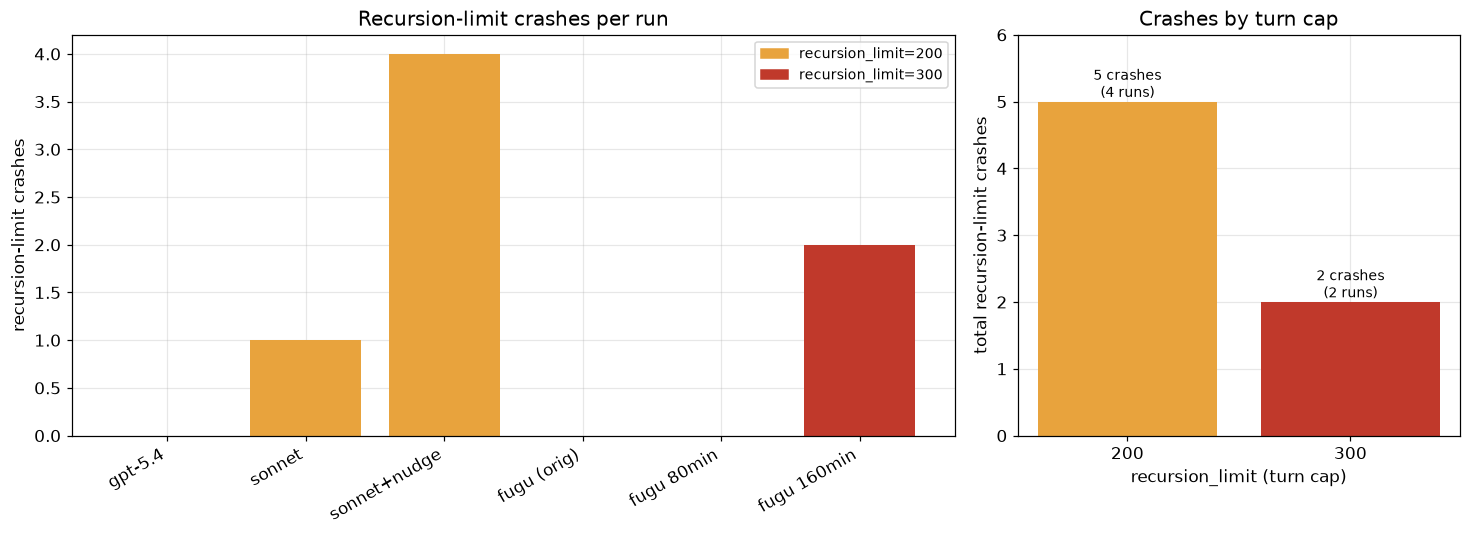

,recursion_limit,runs,rec_fails
0,200,4,5
1,300,2,2


In [13]:
# Per-run recursion-limit crashes, colored by the run's turn cap.
rr = (df.assign(rec_fail=(df["failure"] == "recursion-limit").astype(int))
        .groupby(["run", "label", "recursion_limit"], observed=True)
        .agg(rec_fails=("rec_fail", "sum"), cycles=("cycle", "count")).reset_index()
        .sort_values(["recursion_limit", "label"]))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.5, 5.0), gridspec_kw={"width_ratios": [2, 1]})
cap_color = {200: "#e8a33d", 300: "#c0392b"}
axL.bar(range(len(rr)), rr["rec_fails"], color=[cap_color[c] for c in rr["recursion_limit"]])
axL.set_xticks(range(len(rr))); axL.set_xticklabels([str(l) for l in rr["label"]], rotation=30, ha="right")
axL.set_ylabel("recursion-limit crashes"); axL.set_title("Recursion-limit crashes per run")
import matplotlib.patches as mp
axL.legend(handles=[mp.Patch(color=cap_color[c], label=f"recursion_limit={c}") for c in (200, 300)], fontsize=9)

# Right: totals by cap — the crash survives the bump from 200 -> 300.
by_cap = rr.groupby("recursion_limit", observed=True).agg(
    runs=("run", "nunique"), rec_fails=("rec_fails", "sum")).reset_index()
axR.bar(by_cap["recursion_limit"].astype(str), by_cap["rec_fails"],
        color=[cap_color[c] for c in by_cap["recursion_limit"]])
for x, v, n in zip(by_cap["recursion_limit"].astype(str), by_cap["rec_fails"], by_cap["runs"]):
    axR.text(x, v, f"{int(v)} crashes\n({n} runs)", ha="center", va="bottom", fontsize=9)
axR.set_xlabel("recursion_limit (turn cap)"); axR.set_ylabel("total recursion-limit crashes")
axR.set_title("Crashes by turn cap"); axR.margins(y=0.2)
plt.tight_layout(); plt.show()
by_cap

**Raising the cap 200 → 300 did not stop the crashes** — it only let the agent take more turns before
hitting the wall. Recursion-limit crashes occur at **both** caps (sonnet/sonnet+nudge at 200; fugu
160-min at 300). The fugu **80-min** run (cap 300) had *zero* recursion crashes because the time wall
(80 min) bound first — which is exactly why the failure mode is budget-dependent. The fix isn't a bigger
number; it's a **graceful step-budget path** (a wrap-up nudge + partial-proposal harvest before the hard
limit — issue #103), mirroring what the time budget already has.

## 10. What the objective data says

- **Plateau, not a climb.** Hold-out balanced accuracy sits at **~0.966** across every run and model;
  the best of all is **fugu 0.9668**. After the first couple of cycles, gains are sub-thousandth.
- **The gate held the line.** No run's calibrated estimate reached the **~0.972** competitive bar, so
  **0 cycles accepted** and **0 Kaggle submissions spent** — disciplined withholding, by design.
- **The gap is ~0.005–0.007 and never closes** — consistent with a feature/model **ceiling**, not a
  compute shortage.
- **More time was the wrong lever.** fugu 80min → 160min bought **~+0.0002** for **~+6 h** and *more*
  failures (timeouts → also recursion-limit crashes). The agent expands to fill any budget.
- **Failure modes are budget-dependent:** longer budgets shift the binding wall from **time**
  (timeouts) to **step count** (`recursion-limit` crashes) — see issue #103.

> Re-run after a new run completes: drop its `results.json` under `prototyping-runs/<date>-…/` and
> re-execute — every table and chart updates automatically.